# Loan Default Risk Modeling

---

## 1. Objective
Build and compare predictive models to estimate the probability of loan default.

**Evaluation Metric:** ROC-AUC (chosen due to class imbalance).

---

## 2. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb

DATA_DIR = "D:/home_credit_risk/data"
train = pd.read_csv(f"{DATA_DIR}/application_train.csv")
train.shape


(307511, 122)

---

## 3. Feature Engineering

In [2]:
train["AGE_YEARS"] = (-train["DAYS_BIRTH"] / 365.25).clip(0, 100)

# Modeling features used for baseline comparison
features = ["AGE_YEARS", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

df_model = train[features + ["TARGET"]].dropna()

X = df_model[features]
y = df_model["TARGET"]

X.head()


C:\Users\gmy1999\AppData\Local\Temp\ipykernel_36072\1026520175.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["AGE_YEARS"] = (-train["DAYS_BIRTH"] / 365.25).clip(0, 100)


,AGE_YEARS,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,25.902806,0.083037,0.262949,0.139376
6,37.722108,0.774761,0.724000,0.492060
8,55.028063,0.587334,0.205747,0.751724
10,27.917864,0.319760,0.651862,0.363945
11,55.898700,0.722044,0.555183,0.652897


---

## 4. Logistic Regression Baseline

In [3]:
# Standardize features (important for Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict_proba(X_val)[:, 1]
auc_log = roc_auc_score(y_val, y_pred_log)

print("Logistic Validation AUC:", auc_log)


Logistic Validation AUC: 0.7498367211339699


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Keep index by splitting on DataFrame first
X_df = df_model[features]   # DataFrame (keeps index)
y_sr = df_model["TARGET"]            # Series (keeps index)

X_train_df, X_val_df, y_train, y_val = train_test_split(
    X_df, y_sr, test_size=0.2, random_state=42, stratify=y_sr
)

# Scale AFTER split
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df)
X_val = scaler.transform(X_val_df)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict_proba(X_val)[:, 1]
auc_log = roc_auc_score(y_val, y_pred_log)

print("Logistic Validation AUC:", auc_log)

Logistic Validation AUC: 0.7498311534107688


**Takeaway:** Adding EXT_SOURCE variables significantly improves performance (AUC ≈ 0.75), indicating strong external credit signals.

---

## 5. Coefficient Interpretation

In [13]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

coefficients


,Feature,Coefficient
0,AGE_YEARS,0.220555
2,EXT_SOURCE_2,-0.362303
3,EXT_SOURCE_3,-0.554740
1,EXT_SOURCE_1,-0.562226


**Observation:**
- EXT_SOURCE variables dominate predictive power.
- AGE coefficient may change sign due to conditional effects.

---

## 6. Correlation Analysis

In [14]:
corr_matrix = train[["AGE_YEARS", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].corr()
corr_matrix


,AGE_YEARS,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
AGE_YEARS,1.000000,0.600610,0.091996,0.205478
EXT_SOURCE_1,0.600610,1.000000,0.213982,0.186846
EXT_SOURCE_2,0.091996,0.213982,1.000000,0.109167
EXT_SOURCE_3,0.205478,0.186846,0.109167,1.000000


**Insight:** AGE_YEARS is moderately correlated with EXT_SOURCE_1 (~0.6), which can cause coefficient redistribution under conditional modeling.

---

## 7. ROC Curve

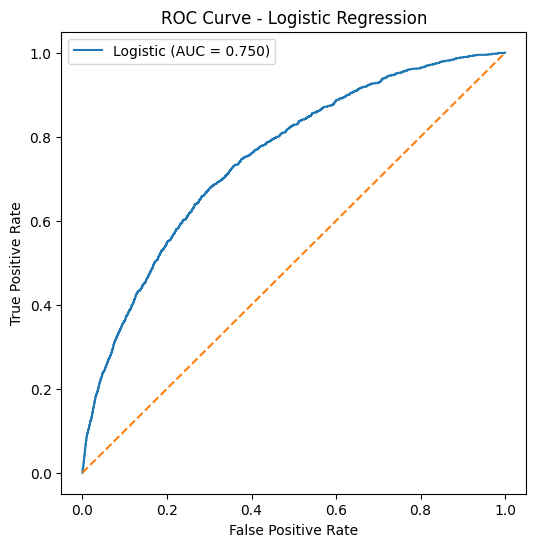

In [15]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred_log)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


---

## 8. LightGBM Baseline

In [16]:
# Tree models do not require scaling
X_train_tree, X_val_tree, y_train_tree, y_val_tree = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

lgb_model.fit(X_train_tree, y_train_tree)

y_pred_lgb = lgb_model.predict_proba(X_val_tree)[:, 1]
auc_lgb = roc_auc_score(y_val_tree, y_pred_lgb)

print("LightGBM Validation AUC:", auc_lgb)


[LightGBM] [Info] Number of positive: 6398, number of negative: 81273
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 87671, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.072977 -> initscore=-2.541828
[LightGBM] [Info] Start training from score -2.541828
LightGBM Validation AUC: 0.7419636375381435


**Result:** LightGBM achieves comparable AUC (~0.74) with this small set of high-information features.

---

## 9. Feature Importance (LightGBM)

In [17]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": lgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance


,Feature,Importance
2,EXT_SOURCE_2,1620
1,EXT_SOURCE_1,1546
0,AGE_YEARS,1436
3,EXT_SOURCE_3,1398


**Interpretation:** Feature importance confirms strong contribution from external credit scores.

---

## 10. Class Imbalance Experiment

In [18]:
# Approximate class ratio from observed counts in training logs
# You can recompute dynamically if needed:
# neg, pos = (y_train_tree == 0).sum(), (y_train_tree == 1).sum()
# scale_weight = neg / pos

scale_weight = 12.7  # approx 81273 / 6398

lgb_balanced = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    scale_pos_weight=scale_weight
)

lgb_balanced.fit(X_train_tree, y_train_tree)

y_pred_bal = lgb_balanced.predict_proba(X_val_tree)[:, 1]
auc_bal = roc_auc_score(y_val_tree, y_pred_bal)

print("LightGBM Balanced AUC:", auc_bal)


[LightGBM] [Info] Number of positive: 6398, number of negative: 81273
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000775 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 87671, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.072977 -> initscore=-2.541828
[LightGBM] [Info] Start training from score -2.541828
LightGBM Balanced AUC: 0.7425954510778618


**Insight:** AUC remains largely stable because ROC-AUC is threshold-independent; class weighting more strongly affects threshold-based metrics (Precision/Recall/F1).

---

## 11. Final Modeling Conclusion

- Logistic Regression achieved strong ranking performance (AUC ≈ 0.75).
- External credit score variables (EXT_SOURCE) are dominant predictors.
- LightGBM delivered comparable performance, suggesting near-linear separability in this feature space.
- Feature quality proved more impactful than model complexity.
- Multicollinearity between age and EXT_SOURCE explains coefficient sign shifts under conditional modeling.

---

## Overall Takeaways

- AUC measures ranking ability, not classification accuracy.
- Tree models are less sensitive to multicollinearity than linear models.
- Precision is heavily influenced by base rate.
- Robust modeling requires monitoring feature stability (drift) and missingness.

In [20]:
import os

os.makedirs("outputs", exist_ok=True)

output_df = pd.DataFrame({
    "SK_ID_CURR": X_val_df.index,          # validation IDs
    "Default_Probability": y_pred_log,
    "Actual_Target": y_val.values
})

output_df["Risk_Decile"] = pd.qcut(
    output_df["Default_Probability"],
    10,
    labels=False
).astype(int) + 1

output_path = "D:/home_credit_risk/outputs/model_predictions.csv"
output_df.to_csv(output_path, index=False)

print("Exported to:", output_path)
output_df.head()

Exported to: D:/home_credit_risk/outputs/model_predictions.csv


,SK_ID_CURR,Default_Probability,Actual_Target,Risk_Decile
0,107962,0.035727,0,4
1,225366,0.015399,0,1
2,202296,0.015823,0,1
3,155738,0.068909,0,7
4,23108,0.092802,0,8
